In [9]:
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import KFold # Added for cross-validation in Ridge Regression

# Show the plots inline in the notebook
%matplotlib inline

import numpy as np
import random

# Visualization packages - matplotlib and seaborn
# Remember that pandas is also handy and capable when it comes to plotting!
import seaborn as sns
import matplotlib.pyplot as plt

# Machine learning package - scikit-learn
from sklearn import metrics
from sklearn.model_selection import train_test_split, cross_val_score, LeaveOneOut, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import KFold # Added for cross-validation in Ridge Regression


In [10]:
np.random.seed(2025)
random.seed(2025)


## Classification using k-nearest neighbors 

We start exploring the world of data modeling by using the K-Nearest Neightbors (k-NN) algorithm. The k-NN algorithm is a classic supervised machine learning technique based on the assumption that data points with similar features tend to belong to the same class, and thus are likely to be near each other in feature space.

In our case, we'll use the k-NN algorithm to *predict the presence of cardiovascular disease* (CVD) using all the other variables as <font color = lightcoral>features</font> in the given data set. I.e. the <font color = lightcoral>target variable</font> that we are interested in is `cardio`. Let's have a brief look at the features again:

| Feature | Type | Explanation |
| :- | :- | :-
| age | numeric | The age of the patient in years 
| sex | binary | Female == 0, Male == 1
| height | numeric | Measured weight of the patient (kg)
| weight | numeric | Measured weight of the patient (cm)
| ap_hi | numeric | Measured Systolic blood pressure
| ap_lo | numeric | Measured Diastolic blood pressure
| smoke | binary | A subjective feature based on asking the patient whether or not he/she smokes
| alco | binary | A subjective feature based on asking the patient whether or not he/she consumes alcohol
| active | binary |  A subjective feature based on asking the patient whether or not he/she exercises regularly
| cholesterol | categorical | Cholesterol associated risk information evaluated by a doctor
| gluc | categorical | Glucose associated risk information evaluated by a doctor

But first, we need data for the task. 


In [11]:
# Path for the data
data_path = 'ex2_cardio_data.csv'

# Read the CSV file 
cardio_data = pd.read_csv(data_path)

# For this task, we are going to use ALL variables but CARDIO as features, and CARDIO as label.
# Find the following specs of the data:

# (1) What is the total number of data samples?
total_samples = cardio_data.shape[0]

# (2) How many distinct classes (target categories) does the dataset contain?
# The target variable is 'cardio'
distinct_classes = cardio_data['cardio'].nunique()

# (3) Which person (their index) is the heaviest in the dataset?
heaviest_index = cardio_data['weight'].idxmax()

# (4) Which feature in the dataset has the largest range (max–min)?
# Select only numeric columns to calculate ranges
numeric_df = cardio_data.select_dtypes(include=['int64', 'float64'])
# Calculate the range (max - min) for all numeric columns
ranges = numeric_df.max() - numeric_df.min()
# Find the feature with the largest range
largest_range_feature = ranges.idxmax()


print(f"(1) Total number of data samples: {total_samples}")
print(f"(2) Number of distinct classes (target categories): {distinct_classes}")
print(f"(3) Index of the heaviest person: {heaviest_index}")
print(f"(4) Feature with the largest range (max – min): {largest_range_feature}")

(1) Total number of data samples: 6000
(2) Number of distinct classes (target categories): 2
(3) Index of the heaviest person: 5912
(4) Feature with the largest range (max – min): ap_hi


In [31]:
# As the notebook may be too slow to run for the full dataset, we will only use 1000 samples 
# from the original data

# Resample with pandas.DataFrame.sample with random_state=2025 and print first 15 rows

cardio_data = cardio_data.sample(n=1000, random_state=2025)
print("\nFirst 15 rows of the 1000-row random sample:")
print(cardio_data.head(15))


First 15 rows of the 1000-row random sample:
      age  sex  height  weight  ap_hi  ap_lo  smoke  alco  active  cardio  \
2666   47    1     163    65.0    120     80      0     0       0       0   
4768   53    0     165    65.0    120     80      0     0       1       1   
306    45    0     164    75.0    140     90      0     0       1       0   
2519   50    0     168    64.0    120     80      0     0       1       0   
3309   56    0     161    80.0    120     70      0     0       1       0   
275    53    0     160    60.0    120     80      0     0       0       0   
123    54    0     160    58.0    120     80      0     0       1       0   
5433   48    0     168    69.0    140    100      0     0       1       1   
3492   52    0     153    50.0    110     70      0     0       1       0   
1472   45    0     165    69.0    100     80      0     0       1       0   
5392   50    0     167    60.0    120     80      0     0       0       1   
4457   63    1     182   115.0

We have the data. All the analyses will be done based on this sample of 1000.

To teach the k-NN algorithm (or any other machine learning algorithm) to recognize patterns, we need training data. However, to assess how well a model has learned these patterns, we require test data which is new and unseen by the trained model. It's important to note that the test set is not revealed to the model until after the training is complete.


Gather the features into one array and the target variable into another array. Create training and test data by splitting the data into training (80%) and test (20%) sets. 


In [ ]:
###Train-test split

# As we are going to use ALL THE OTHER BUT CARDIO as features, we can drop the cardio column like this
features = cardio_data.drop(columns=['cardio'])

# and as labels, basically just choose the cardio column as follows
labels = cardio_data['cardio']


label_counts = labels.value_counts(normalize=True) * 100
print(f"Label Distribution:\n{label_counts.to_markdown(numalign='left', stralign='left')}")

#TRAIN-TEST SPLIT
# Use sklearn.model_selection.train_test_split() function with random_state=2025

features_train, features_test, labels_train, labels_test = train_test_split(features,
                                                                            labels,
                                                                            random_state=2025,
                                                                            test_size=0.2,
                                                                            stratify=labels)

print("\nTrain-Test Split complete.")
print(f"Training set size: {features_train.shape[0]} samples (80%)")
print(f"Test set size: {features_test.shape[0]} samples (20%)")

Label Distribution:
| cardio   | proportion   |
|:---------|:-------------|
| 0        | 69.9         |
| 1        | 30.1         |

Train-Test Split complete.
Training set size: 800 samples (80%)
Test set size: 200 samples (20%)



Standardize the numerical features in both the train and test sets.

In [34]:
### Standardization

# We wanted to scale only the numeric variables so we can have them in a list as
numeric_features = ['age', 'weight', 'height', 'ap_hi', 'ap_lo']

scaler = StandardScaler()

# Fit a StandardScaler and scale the data using the computed mean and std
scaled_features_train = features_train.copy()
scaled_features_train[numeric_features] = (scaled_features_train[numeric_features].astype(float))


scaled_features_train[numeric_features] = scaler.fit_transform(scaled_features_train[numeric_features])

# then the test set (features_test)
scaled_features_test = features_test.copy()
scaled_features_test[numeric_features] = (scaled_features_test[numeric_features].astype(float))


scaled_features_test[numeric_features] = scaler.transform(scaled_features_test[numeric_features])

- The k-NN model predicts cardiovascular disease (CVD) by calculating the Euclidean distance between data points. When features are not standardized, variables with a larger numerical range (blood pressure, ap_hi) overwhelmingly dominate the distance calculation. This will make the model to prioritize changes in the largest-scale features, effectively masking the influence of critical smaller-scale features like age or weight, leading to biased predictions.

- Standardization scales all features to have a mean of 0 and a standard deviation of 1. This process eliminates the bias caused by varying scales, ensuring that every feature contributes equally to the distance metric. As a result, k-NN accurately assesses patient similarity based on the relative importance of all health indicators, leading to significantly improved predictive accuracy.


Train a k-NN model with $k=3$. Print out the confusion matrix and use it to compute the accuracy, the precision and the recall.


In [ ]:
### Use the kNN classifier sklearn.neighbors.KNeighborsClassifier() with k =3

 
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(scaled_features_train, labels_train)
predicted_labels = knn_model.predict(scaled_features_test)
# Confusion matrix. Use sklearn.metrics.confusion_matrix() to build it


conf_matrix = metrics.confusion_matrix(labels_test, predicted_labels)
print("Confusion Matrix:")
print(conf_matrix)

# Accuracy, precision and recall. Use previously built confusion matrix to calculate metrics
TN = conf_matrix[0, 0]
FP = conf_matrix[0, 1]
FN = conf_matrix[1, 0]
TP = conf_matrix[1, 1]

# Calculate metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)

# Compare the results you got to the baselines by sklearn.metrics:
print()
print(f'Accuracy: {metrics.accuracy_score(labels_test, predicted_labels):.3f}')
print(f'Precision: {metrics.precision_score(labels_test, predicted_labels):.3f}')
print(f'Recall: {metrics.recall_score(labels_test, predicted_labels):.3f}')


Confusion Matrix:
[[114  26]
 [ 32  28]]

Accuracy: 0.710
Precision: 0.519
Recall: 0.467




Confusion Matrix Representation: Each cell of the confusion matrix represents a type of outcome for the 200 patients in the test set:

- True Negative (TN = 115): Patients who truly didn't have CVD and were correctly predicted as not having CVD.
- False Positive (FP = 25): Patients who truly didn't have CVD but were incorrectly predicted as having CVD (a "false alarm").
- False Negative (FN = 36): Patients who truly had CVD but were incorrectly predicted as not having CVD (a serious "missed case").
- True Positive (TP = 24): Patients who truly had CVD and were correctly predicted as having CVD.

Performance Interpretation and Differences

The model performs better on the majority class (No CVD / Class 0) than the minority class (CVD / Class 1).
- Performance on No CVD (Class 0): High, as indicated by the high TN count (115)
- Performance on CVD (Class 1): Poor, as indicated by the high FN count (36) compared to the TP count (24). The model only identifies 40% of the actual CVD cases (Recall: 0.400)
- Source of Differences: The difference primarily comes from the class imbalance in the dataset (approximately 70% No CVD vs. 30% CVD). The k-NN algorithm tends to be biased toward the majority class because a random neighbor is more likely to belong to the larger group, making it harder to accurately predict the less common CVD cases. The low Precision (0.490) shows that when the model does predict CVD, it is only correct less than half the time, indicating high uncertainty.

Caution in Interpreting Accuracy

We should be cautious when interpreting the Accuracy (0.695) because our dataset is imbalanced. Since 70% of the patients do not have CVD, a naive model that just simply predicted "No CVD" for every patient would still achieve an accuracy of 70%. Our model's accuracy of 69.5% is not substantially better than this baseline, despite the model having learned patterns. The low Recall is the critical metric here, as it reveals the model's failure to correctly identify 60% of the actual CVD cases. In a medical context, missing true disease cases (high FN) is often the more costly error, and accuracy alone fails to capture this deficiency.


##  Classification accuracy using leave-one-out cross-validation


Let's keep the focus on detecting the CVD, so once again we utilize the k-NN model (with $k=3$) to predict the precense of the disease. 

In [37]:
### Leave-one-out cross-validation

# Either manually loop through the LOOCV or use the optimized 
# sklearn.model_selection.cross_val_score() function.

loocv = LeaveOneOut()

cv_scores = cross_val_score(
    knn_model, 
    features, 
    labels, 
    cv=loocv, 
    scoring='accuracy',
    n_jobs=-1
)

# Print results
print(f"Number of cross-validation iterations (folds): {len(cv_scores)}")
print(f"\nMean LOOCV Accuracy: {np.mean(cv_scores):.3f}")
print(f"Standard Deviation of LOOCV Accuracy: {np.std(cv_scores):.3f}")

Number of cross-validation iterations (folds): 1000

Mean LOOCV Accuracy: 0.716
Standard Deviation of LOOCV Accuracy: 0.451




2a) The Mean LOOCV Accuracy (0.716) is slightly higher than the single Train-Test Split Accuracy (0.695) I got in the previous task. The primary takeaway is not the numerical difference, but the stability of the LOOCV estimate. By evaluating the model across 1000 distinct train/test splits, the LOOCV result gives a more robust and unbiased measure of the model's true performance compared to relying on a single, potentially lucky split. The results confirm that the model's performance consistently is around 70-72% accuracy.


2b)The k-NN model (with k=3) is not suitable for reliably addressing the problem of CVD detection with this dataset.

- Low predictive value: The robustly estimated mean accuracy (0.716) is barely better than the 70% baseline accuracy achieved by simply predicting the majority class ("No CVD") every time. This indicates the model has learned very little true predictive signal.
- Critical Failure on Minority Class: The most significant issue is the model's performance on the clinically relevant minority class (CVD). As observed in Exercise 1 D, the Recall was only 0.400, meaning the model failed to identify 60% of the patients who actually have CVD (False Negatives).
- Not suitable as a classifier for this task: A classifier that misses the majority of positive disease cases is unreliable and potentially dangerous in a medical context. The k-NN model is failing to map the complex decision boundary for the minority class due to the data's inherent class imbalance, rendering it ineffective for this specific classification task.


## Model selection with leave-one-out cross-validation

In [38]:
### Select best model
# Define the range of k values to test (1 to 30)
k_range = range(1, 31)
param_grid = dict(n_neighbors=k_range)

 
features_scaled = features.copy()
# Fit and transform the scaler on the full dataset
features_scaled[numeric_features] = scaler.fit_transform(features_scaled[numeric_features].astype(float))

# Instantiate GridSearchCV
# n_jobs=-1 uses all available processors to speed up the process
grid = GridSearchCV(
    estimator=KNeighborsClassifier(), 
    param_grid=param_grid, 
    cv=loocv, 
    scoring='accuracy', 
    n_jobs=-1
)

# Fit the grid search to the data
print("Grid Search")
grid.fit(features_scaled, labels)

# Print the best results
print(f"Optimal k value: {grid.best_params_['n_neighbors']}")
print(f"Best Accuracy: {grid.best_score_:.4f}")

# Get the mean accuracy scores for each value of k
mean_scores = grid.cv_results_['mean_test_score']

Grid Search
Optimal k value: 9
Best Accuracy: 0.7500


The optimal value found by your search is k=9, which achieved an accuracy of 0.750. This is an improvement over our previous model with k=3, which had an accuracy of around 0.716. While the jump in accuracy isn't massive, it shows that looking at more neighbors helps smooth out the noise and provides a slightly more reliable prediction for this dataset.

If the number of k is increased further (approaching the total number of samples, N), the accuracy approaches the baseline accuracy of the majority class (approximately 0.70 or 70%). As k -> N, the model eventually considers the entire training set as "neighbors" for every prediction. Since the majority class (No CVD) makes up around 70% of the data, the majority vote will always be "No CVD," regardless of the input features. The model essentially becomes a constant predictor of the majority class.

The impact of choosing a:

- Very Small k (such as k=1): The model becomes overly complex (high variance). It reacts to every distinct detail and noise in the training data. This creates a jagged, unstable decision boundary that fits the training data perfectly but fails to generalize, likely misclassifying outliers as distinct patterns.

- Very Large k: The model becomes overly simple (high bias). By averaging over a huge neighborhood, it smooths out the decision boundary too much, washing out the subtle distinctions between healthy individuals and those with CVD. It eventually ignores local patterns entirely and defaults to the majority trend.

# Plot the accuracies as a function of <i>k</i>


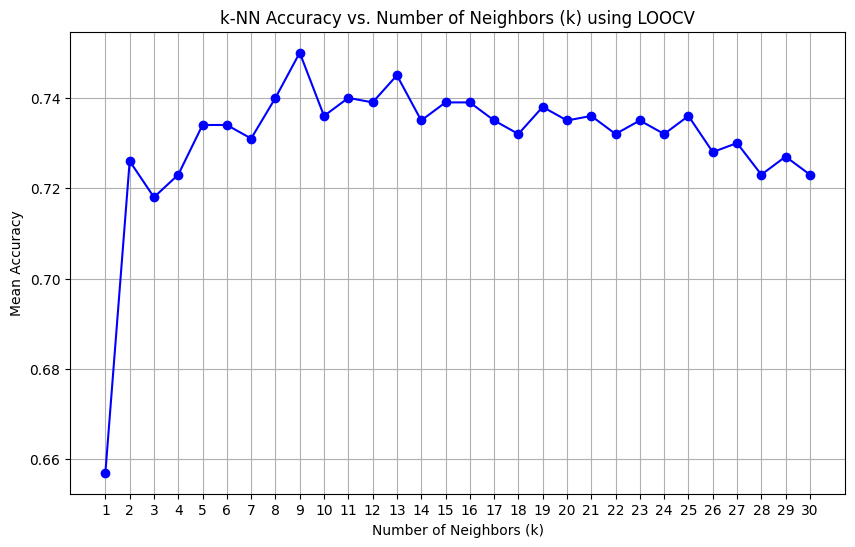

In [39]:
### Plot the accuracies vs. the values for k
# Plot accuracies vs. k values

plt.figure(figsize=(10, 6))
plt.plot(k_range, mean_scores, marker='o', linestyle='-', color='b')
plt.title('k-NN Accuracy vs. Number of Neighbors (k) using LOOCV')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean Accuracy')
plt.grid(True)
plt.xticks(k_range) # Show all k values on x-axis
plt.show()

Observation:

- The Rise: At very low k (k=1), the accuracy is lower. This is because the model is too sensitive to "noise" - if a healthy person has weird test results, the model gets confused easily. As k increases toward 9, the line rises. The model starts listening to more neighbors, "smoothing" out those noisy outliers and making better decisions.
- The Peak (Optimal Balance): The curve hits its highest point at k=9 (accuracy around 0.75). At this spot, the model is complex enough to capture patterns but simple enough to ignore noise.
- The Decline (Increase of Bias): After k=9, the line starts to slowly drop down. As I add too many neighbors, the model starts to "underfit." It stops seeing the detailed boundaries between sick and healthy patients and starts defaulting to the majority opinion (which is "healthy" in this dataset). The distinct patterns get washed out by the crowd.

# What if the number of <i>k</i> still increases? Experiment with the <i>k</i> values of $201-230$


Grid Search for k = 201 to 230


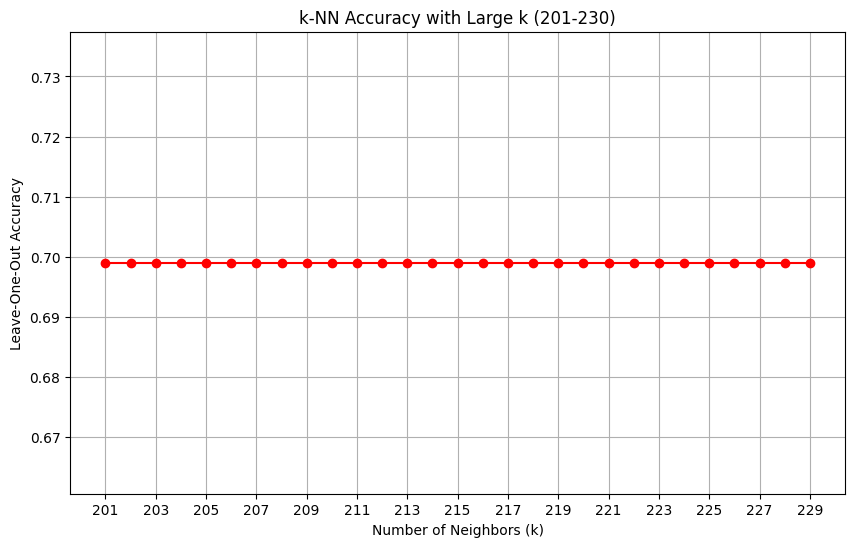

In [40]:
# If the number of k still increases?
# try really large k values (200-251) and see what happens to the final accuracy
#Define the new high range for k
k_range_large = range(201, 230)
param_grid_large = {'n_neighbors': k_range_large}



#Instantiate a NEW GridSearchCV for this specific range
#Re-use the same 'loocv' and 'features_scaled' 
grid_search_large = GridSearchCV(
    estimator=KNeighborsClassifier(), 
    param_grid=param_grid_large, 
    cv=loocv, 
    scoring='accuracy', 
    n_jobs=-1
)

#Run the search
print("Grid Search for k = 201 to 230")
grid_search_large.fit(features_scaled, labels)

mean_scores_large = grid_search_large.cv_results_['mean_test_score']

#Plot Accuracies vs. High k
plt.figure(figsize=(10, 6))
plt.plot(k_range_large, mean_scores_large, marker='o', linestyle='-', color='red')
plt.title('k-NN Accuracy with Large k (201-230)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Leave-One-Out Accuracy')
plt.xticks(range(201, 231, 2)) # Show every second tick for readability
plt.grid(True)
plt.show()

 Observation

- The Trend is Flat and Low: we will observe that the accuracy line is flat or very slowly declining, hovering steadily around 0.70 (70%). Unlike the earlier graph (k= 1->30) where there was a clear peak, this line seems like it doesn't show any variation.
- Convergence to the Baseline: the accuracy settles at 0.70 because 70% of the patients in the dataset belong to the "No CVD" class. When k is this large (over 200), the model looks at 20% of the entire dataset to make a single prediction. This large sample size almost always reflects the overall dataset distribution. Since healthy patients are the majority, the "vote" is almost always "Healthy".
- High Bias: This trend shows High Bias. The model has become too simple. It has smoothed out all the useful local patterns and complexities of the data. It is no longer distinguishing between patients based on their specific health metrics; it is simply predicting the majority class for everyone.

______________
## <font color = lightcoral>4.  Data Loading and Initial Exploration for (Prostate Cancer) dataset </font>



Here's a brief overview of the features in our dataset:

| Feature | Type | Explanation |
| :- | :- | :-
| lcavol | numeric | log cancer volume
| lweight | numeric | log prostate weight
| age | numeric | patient's age
| lbph | numeric | log of benign prostatic hyperplasia amount
| svi | boolean | seminal vesicle invasion (0=no, 1=yes)
| lcp | numeric | log of capsular penetration
| gleason | numeric | Gleason score
| pgg45 | numeric | percentage of Gleason score 4+5
| lpsa | numeric | log PSA level (target variable)


Load the prostate dataset and display summary statistics (mean, std, min, max) for all numeric variables.
 



In [41]:
#  Load prostate data
cancerData = pd.read_csv('prostate.csv')

#  Display the first 5 rows of cancerData
print("First 5 rows:")
display(cancerData.head())

#  Display the number of unique values per column
print("\nUnique values per column:")
display(cancerData.nunique())

#  Display summary statistics of the dataset
print("\nSummary statistics:")
display(cancerData.drop(columns=['svi']).describe())

First 5 rows:


,lcavol,lweight,age,lbph,svi,lcp,gleason,pgg45,lpsa
0,-0.579818,2.769459,50,-1.386294,0,-1.386294,6,0,-0.430783
1,-0.994252,3.319626,58,-1.386294,0,-1.386294,6,0,-0.162519
2,-0.510826,2.691243,74,-1.386294,0,-1.386294,7,20,-0.162519
3,-1.203973,3.282789,58,-1.386294,0,-1.386294,6,0,-0.162519
4,0.751416,3.432373,62,-1.386294,0,-1.386294,6,0,0.371564



Unique values per column:


lcavol     93
lweight    88
age        31
lbph       42
svi         2
lcp        30
gleason     4
pgg45      19
lpsa       85
dtype: int64


Summary statistics:


,lcavol,lweight,age,lbph,lcp,gleason,pgg45,lpsa
count,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000
mean,1.350010,3.628943,63.865979,0.100356,-0.179366,6.752577,24.381443,2.478387
std,1.178625,0.428411,7.445117,1.450807,1.398250,0.722134,28.204035,1.154329
min,-1.347074,2.374906,41.000000,-1.386294,-1.386294,6.000000,0.000000,-0.430783
25%,0.512824,3.375880,60.000000,-1.386294,-1.386294,6.000000,0.000000,1.731656
50%,1.446919,3.623007,65.000000,0.300105,-0.798508,7.000000,15.000000,2.591516
75%,2.127041,3.876396,68.000000,1.558145,1.178655,7.000000,40.000000,3.056357
max,3.821004,4.780383,79.000000,2.326302,2.904165,9.000000,100.000000,5.582932


Plot pairwise relationships between the `lpsa` variable and all other features using `seaborn.pairplot` with the following parameters: `kind="reg"`, `diag_kind="kde"`, and `plot_kws={"line_kws": {"color": "red"}}`.

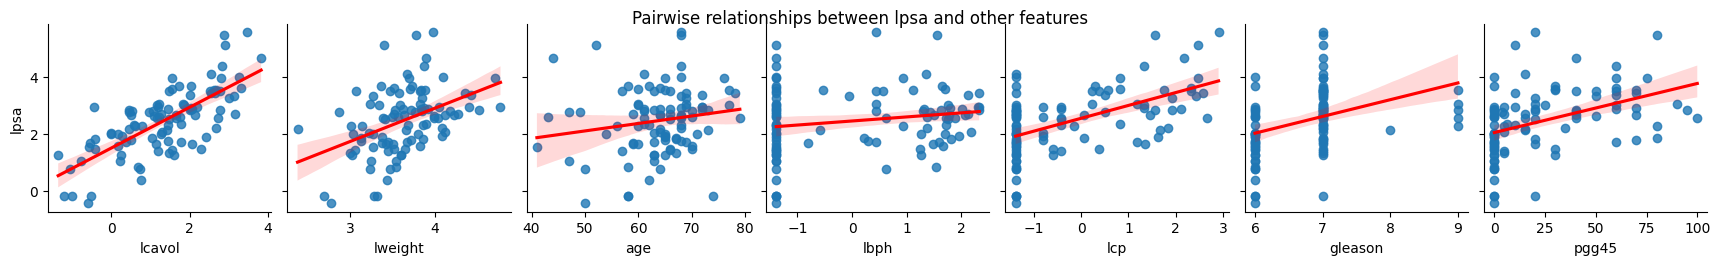

In [42]:
#  Import necessary packages
import seaborn as sns

#Select numeric columns from cancerData
numeric_features = cancerData.select_dtypes(include=['number']).columns.tolist()

#Remove 'lpsa' and 'svi' from the feature list
features_for_pairplot = [col for col in numeric_features if col not in ['svi', 'lpsa']]

#Create the pairplot
pairplot_fig = sns.pairplot(cancerData, 
                            x_vars=features_for_pairplot,
                            y_vars=['lpsa'],
                            kind="reg", 
                            diag_kind="kde", 
                            plot_kws={"line_kws": {"color": "red"}})

#Add a title to the figure
pairplot_fig.fig.suptitle("Pairwise relationships between lpsa and other features", y=1.02)
plt.show()


## Ridge Regression 


Having explored the relationships within our data, we are now ready to delve into regression modeling. This section will focus on <font color = royalblue>Ridge Regression</font>, a powerful regularization technique for predicting continuous outcomes. Our objective is to build a Ridge Regression model that can accurately estimate `lpsa` levels based on the other features in the dataset.

Before we train our model, it's crucial to prepare the data appropriately. This involves splitting the dataset into training and testing sets, and standardizing features to ensure optimal model performance, especially for regularization techniques like Ridge Regression.


1. Separate the features (X) from the target variable (`lpsa`).
2. Split the data into training (80%) and testing (20%) sets using `train_test_split(X, y, test_size=0.2, random_state=2025, shuffle=True)`. Set a `random_state` for reproducibility.
3. Standardize the features for both the training and testing sets using `StandardScaler()`.





In [43]:
#  Import necessary packages
from sklearn.model_selection import train_test_split

#  Separate X and y
X = cancerData.drop('lpsa', axis=1)
y = cancerData['lpsa']
 
#  Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=2025, 
    shuffle=True
)
 
#  Standardize features
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the testing data using the SAME scaler (no fitting here!)
X_test_scaled = scaler.transform(X_test)

#  Print results
print(f"Training features shape: {X_train_scaled.shape}")
print(f"Testing features shape: {X_test_scaled.shape}")

Training features shape: (77, 8)
Testing features shape: (20, 8)


Train a Ridge Regression model (with `Ridge(alpha=100, random_state=2025)`) using the scaled training data. Evaluate the model on both the training and testing sets using Mean Squared Error (MSE). 

In [44]:
#  Create Ridge model with alpha=100
ridge = Ridge(alpha=100, random_state=2025)
#  Fit the model
ridge.fit(X_train_scaled, y_train)

#  Predict on training and test data
y_train_pred = ridge.predict(X_train_scaled)
y_test_pred = ridge.predict(X_test_scaled)

# Calculate Mean Squared Error (MSE)
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

#  Print evaluation results
print(f"Training MSE: {mse_train:.4f}")
print(f"Testing MSE: {mse_test:.4f}")

Training MSE: 0.5929
Testing MSE: 0.7245


- As expected, the Testing MSE is higher than the Training MSE. This is a standard behavior in machine learning because the model is optimized to minimize error on the training data, and the testing data introduces new, unseen variations. The model generalizes reasonably well. The gap between the training and testing error is approximately 0.13. This isn't a massive divergence (which would indicate severe overfitting), nor are the values extremely high (which would indicate severe underfitting, given the target variance is around 1.33).

- "alpha=100" wasn't too strong. If the regularization were too strong, the model would be too simple (underfitted), causing the Training MSE to be very high and close to the Test MSE. Since there is still a distinct gap between the two errors, the model keep enough flexibility to learn patterns, suggesting alpha=100 is acceptable, though hyperparameter tuning could confirm the optimal value.


## Hyperparameter Tuning with Cross-Validation 


Selecting the optimal hyperparameters is crucial for maximizing ML model performance. This is where hyperparameter tuning comes into play, often coupled with cross-validation to ensure robust and reliable model selection.

Cross-validation helps us estimate how well a model will perform on unseen data, providing a more stable evaluation than a single train–test split-especially when fine-tuning hyperparameters. In this section, we will use K-Fold cross-validation to identify the best `alpha` (regularization strength) for our Ridge Regression model.

Before tuning hyperparameters, it is important to remember the purpose of the data split:

* **Training set:** used to fit (train) the model.
* **Validation (via cross-validation):** used to evaluate model performance during tuning **without** touching the test set.
* **Test set:** used only once at the very end to estimate final model performance **after** all tuning decisions are complete.

Using the test set during hyperparameter tuning would lead to overly optimistic results.
Therefore, we rely on K-Fold cross-validation applied to the training data to select hyperparameters in a robust and unbiased way.



Perform K-Fold cross-validation (e.g., with 5 folds) to find the optimal `alpha` value for Ridge Regression from a predefined range of `alphas` (e.g., `np.logspace(-2, 10, num=13)`). Plot the training MSE and cross-validation MSE against the `alpha` values. Highlight the `alpha` value that yields the lowest cross-validation MSE.
Use a logarithmic x-axis (plt.xscale('log')) for the alpha values.



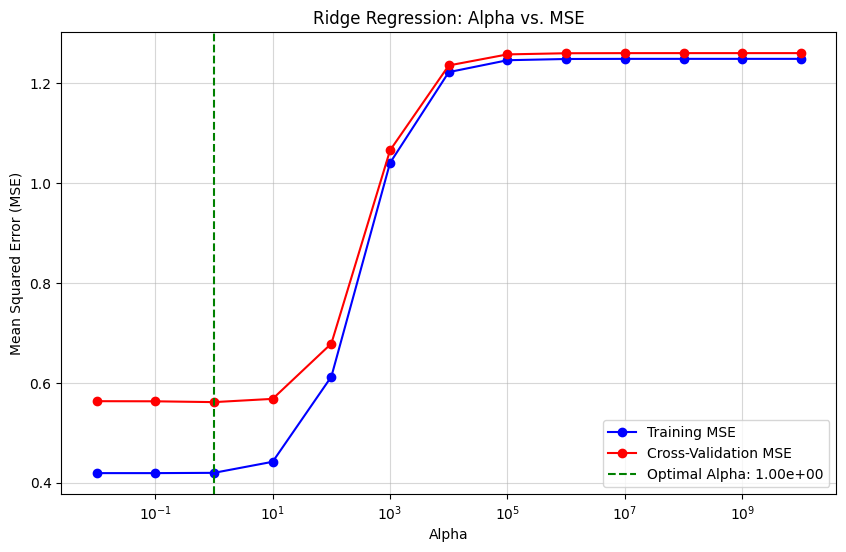

Best alpha value: 1.0


In [45]:
from sklearn.model_selection import cross_validate
#Define alphas
alphas = np.logspace(-2, 10, num=13)

#Create lists to store MSE values
train_mses = []
cv_mses = []

#Create KFold object
kf = KFold(n_splits=5, shuffle=True, random_state=2025)

#Loop over each alpha and compute train MSE and CV MSE
for alpha in alphas:
    ridge = Ridge(alpha=alpha, random_state=2025)
    #neg_mean_squared_error returns negative values, so I negate them later
    scores = cross_validate(ridge, X_train_scaled, y_train, cv=kf, 
                            scoring='neg_mean_squared_error', return_train_score=True)
    
    # Store mean MSEs
    train_mses.append(-np.mean(scores['train_score']))
    cv_mses.append(-np.mean(scores['test_score']))

#Plot training and CV MSE vs alpha
plt.figure(figsize=(10, 6))
plt.plot(alphas, train_mses, marker='o', label='Training MSE', color='blue')
plt.plot(alphas, cv_mses, marker='o', label='Cross-Validation MSE', color='red')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Ridge Regression: Alpha vs. MSE')
plt.grid(True, which="both", ls="-", alpha=0.5)

#Identify and mark the best alpha
best_index = np.argmin(cv_mses)
best_alpha = alphas[best_index]

plt.axvline(best_alpha, color='green', linestyle='--', label=f'Optimal Alpha: {best_alpha:.2e}')
plt.legend()

plt.show()

print("Best alpha value:", best_alpha)

This is significantly smaller than the previous alpha=100.

Finding that the optimal alpha (1.0) is much lower than 100 shows that the initial model with alpha=100 was over-regularized. While it wasn't broken (it still learned patterns), the high penalty on the coefficients was suppressing the model's flexibility more than necessary. With reducing alpha to 1.0, the model can better fit the data without overfitting -> lower Mean Squared Error.

Train the Ridge Regression model again using the optimal `alpha` value found above. Print the Mean Squared Error (MSE) for both the training and test sets, and compare the results with the previous model is trained with `alpha=100` before


In [46]:
#  Create Ridge model using best_alpha
ridge = Ridge(alpha=best_alpha, random_state=2025)

#  Fit model to the training data
ridge.fit(X_train_scaled, y_train)

#  Predict on training and test sets
y_train_pred_opt = ridge.predict(X_train_scaled)
y_test_pred_opt = ridge.predict(X_test_scaled)

# Calculate MSEs
mse_train_opt = mean_squared_error(y_train, y_train_pred_opt)
mse_test_opt = mean_squared_error(y_test, y_test_pred_opt)

#  Print evaluation results and compare between models trained with best_alpha and alpha=100
print(f"Results with Optimal Alpha {best_alpha}")
print(f"Training MSE: {mse_train_opt:.4f}")
print(f"Testing MSE:  {mse_test_opt:.4f}")

#values from exercise 5B
mse_train_old = 0.5929
mse_test_old = 0.7245

print(f"Improvement in Training MSE: {mse_train_old - mse_train_opt:.4f}")
print(f"Improvement in Testing MSE:  {mse_test_old - mse_test_opt:.4f}")

Results with Optimal Alpha 1.0
Training MSE: 0.4323
Testing MSE:  0.5535
Improvement in Training MSE: 0.1606
Improvement in Testing MSE:  0.1710


- Training MSE: a lower error compared to the previous model (0.59). With less regularization (alpha=1 vs alpha=100), the model is allowed to fit the training data much more closely.

- Testing MSE: a significant drop in the test error. This shows that alpha=100 was indeed too strong and was preventing the model from capturing useful patterns. The optimal model generalizes much better.

Using the Ridge Regression model with the optimal `alpha` that was found

In [47]:
### Code - Ridge Regression Equation

#Re-fit the best Ridge model using the optimal alpha found in Exercise 3 A
ridge_optimal = Ridge(alpha=1.0, random_state=2025)
ridge_optimal.fit(X_train_scaled, y_train)

#Let's write the equation
intercept = ridge_optimal.intercept_
coefficients = ridge_optimal.coef_
feature_names = X.columns  # Getting feature names from the original X DataFrame

# tart the equation string with the intercept
equation = f"lpsa = {intercept:.4f}"

#Loop through features and coefficients to build the rest of the string
for name, coef in zip(feature_names, coefficients):
    equation += f" + ({coef:.4f} * {name})"

print("Ridge Regression Equation (Standardized Features):")
print(equation)

Ridge Regression Equation (Standardized Features):
lpsa = 2.4888 + (0.7052 * lcavol) + (0.1592 * lweight) + (-0.1863 * age) + (0.1788 * lbph) + (0.2526 * svi) + (-0.1778 * lcp) + (0.0240 * gleason) + (0.1767 * pgg45)


- The intercept (2.4888) represents the predicted log prostate cancer antigen (lpsa) level for an "average" patient—specifically, a patient whose values for all features (like age, weight) are exactly at the population mean (0)

First, I retrained the model using that optimal alpha we found earlier. To "see" the model, I extracted the intercept (the baseline value) and the coefficients (the weights). I wrote a loop to stitch these together into a readable mathematical formula (y = intercept + w1x1 + ...). This step was important because it gives us the exact "recipe" the model uses to predict lpsa based on the standardized features.

In [48]:
### Code - Visualize Coefficients

# Create a DataFrame for easier plotting
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': ridge_optimal.coef_
})

# Sort by absolute coefficient value for better visualization
#create a column for absolute values to sort, ensuring the most important features are at the top
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)

Next, I visualized the weights. I put the coefficients into a DataFrame but realized that just sorting them by value might be misleading because a large negative number is just as "strong" of a predictor as a large positive one. So, I added a step to calculate the absolute value (Abs_Coefficient) and sorted the data by that. This makes sure the most important features (whether positive or negative) show up at the top of my list.

C:\Users\HP\AppData\Local\Temp\ipykernel_28440\530561714.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')


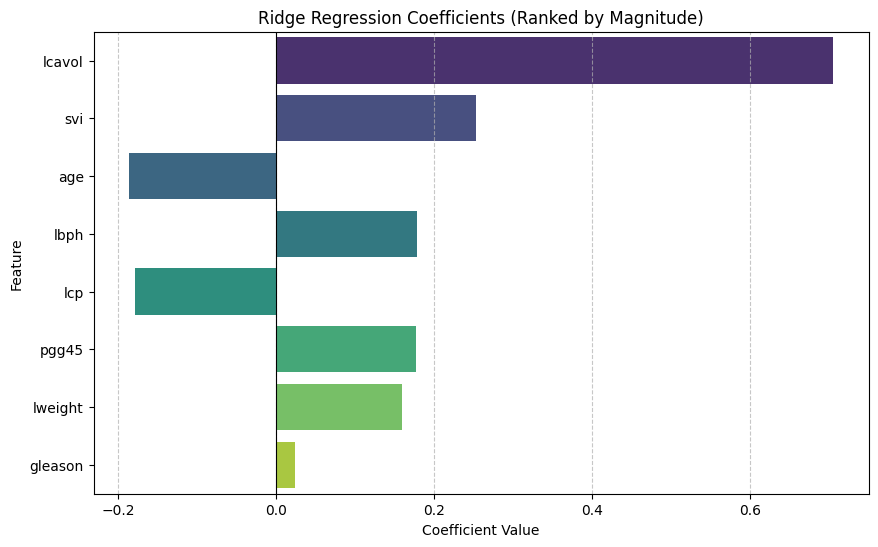

In [49]:
# Create horizontal bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')
plt.title('Ridge Regression Coefficients (Ranked by Magnitude)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.axvline(0, color='black', linewidth=0.8) # Add a line at 0 for clarity
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.show()


Finally, I plotted this sorted list as a horizontal bar chart. I added a vertical black line at zero to clearly separate the features that increase the risk (positive bars, like lcavol) from the ones that decrease it (negative bars). This visual makes it super obvious at a glance that Cancer Volume (lcavol) is the heavyweight champion in predicting the PSA level, while other factors play much smaller roles.

- The feature with the largest coefficient is lcavol: This tells us that lcavol is the most dominant predictor of PSA levels in this dataset.

- Because the data is standardized, we can directly compare the "strength" of features. The fact that lcavol's bar is significantly longer than the others indicates that changes in cancer volume have a much larger impact on the PSA score than any other factor (like age or weight).

## Regularization Path Analysis

Visualize how coefficients change as the regularization strength (alpha) varies. This is called a regularization path or coefficient path.

1. Train Ridge Regression models for a range of alpha values (e.g., `np.logspace(-2, 4, num=50)`)
2. For each alpha, extract the coefficients
3. Plot the coefficient paths: each feature's coefficient value vs. log(alpha)
4. Add a vertical line at the optimal alpha found.

 


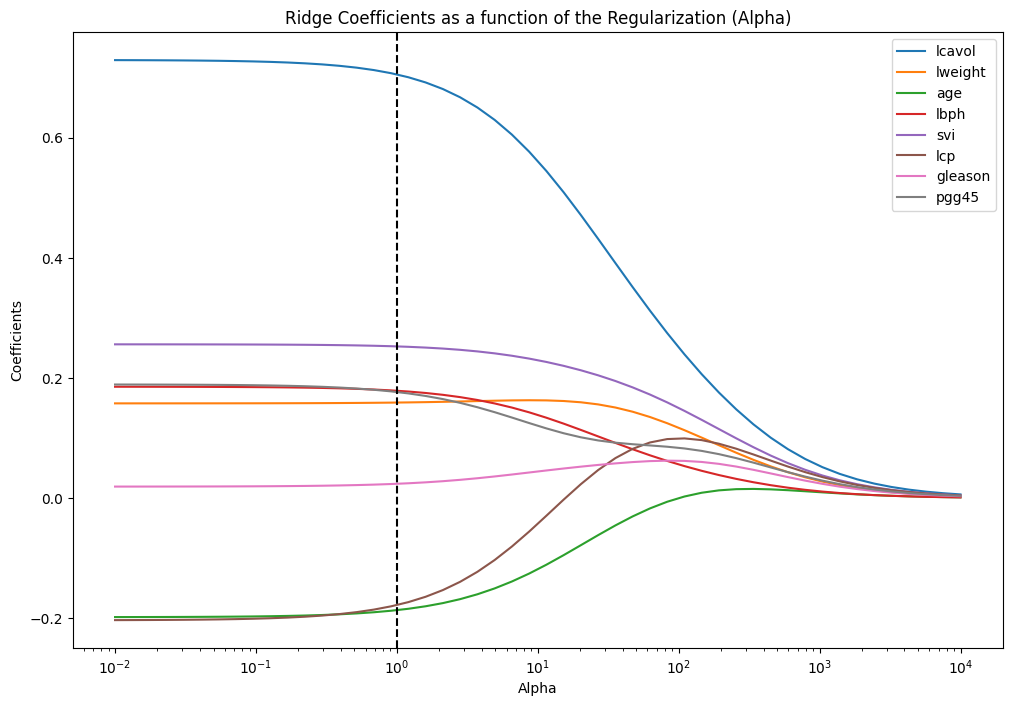

In [50]:
### Code - Regularization Path Analysis

#Define a range of alpha values
alphas = np.logspace(-2, 4, num=50)

#Store coefficients for each alpha
coefs = []
for a in alphas:
    ridge = Ridge(alpha=a, random_state=2025)
    ridge.fit(X_train_scaled, y_train)
    coefs.append(ridge.coef_)


#Plot coefficient paths
plt.figure(figsize=(12, 8))
ax = plt.gca()

#Plot the coefficients vs alpha
ax.plot(alphas, coefs)

#Use a logarithmic scale for the x-axis (alpha)
ax.set_xscale('log')

# Labeling
plt.xlabel('Alpha')
plt.ylabel('Coefficients')
plt.title('Ridge Coefficients as a function of the Regularization (Alpha)')
plt.axis('tight')

#Add a legend for the features using the column names from X
plt.legend(X.columns, loc='upper right')


#Add vertical line at optimal alpha
plt.axvline(best_alpha, linestyle='--', color='black', label=f'Optimal Alpha: {best_alpha}')

plt.show()

## Comparison with Lasso Regression

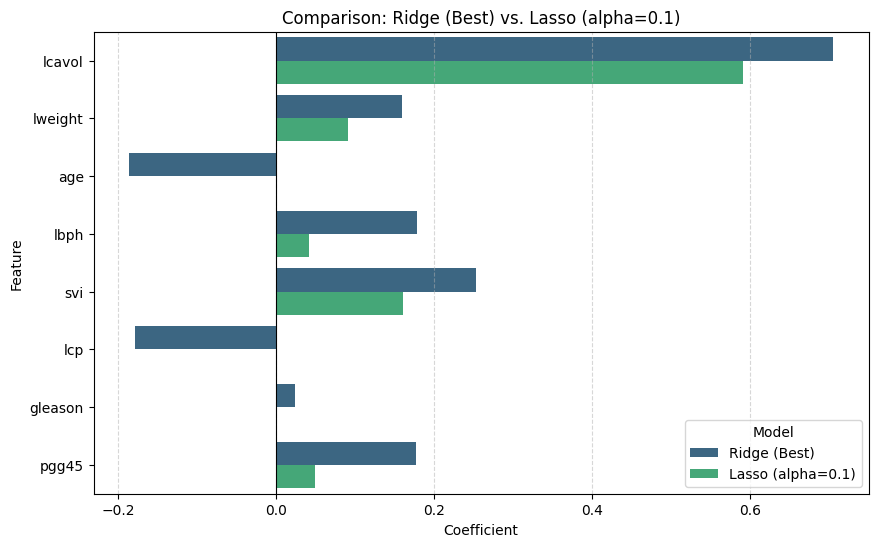

Performance Comparison (Fixed Alpha)
Ridge (Best):      MSE=0.5535, R2=0.6486
Lasso (alpha=0.1): MSE=0.6067, R2=0.6148
--------------------------------------------------
Optimal Alpha for Lasso found: 0.006952


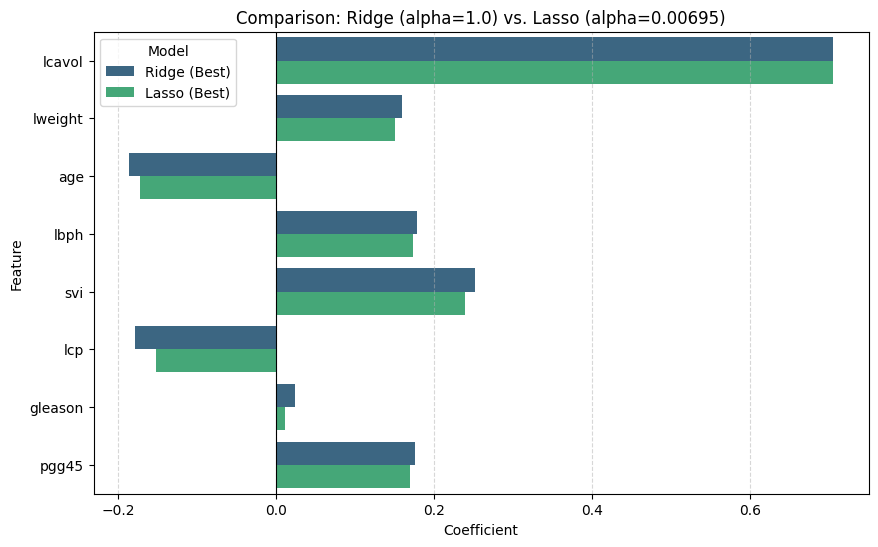

In [51]:
### Code - Comparison with Lasso Regression

# 1. Import: Import the Lasso class from sklearn.linear_model
from sklearn.linear_model import Lasso


# 2. Lasso Training (Fixed Alpha): 
#Train a Lasso model using X_train_scaled and y_train with alpha = 0.1
lasso_fixed = Lasso(alpha=0.1, random_state=2025)
lasso_fixed.fit(X_train_scaled, y_train)

#(Helper for comparison) Train the optimal Ridge model to compare against
#Best Ridge Alpha found in Exercise 6
best_alpha_ridge = 1.0
ridge_best = Ridge(alpha=best_alpha_ridge, random_state=2025)
ridge_best.fit(X_train_scaled, y_train)


# 3. Coefficient Comparison (Fixed Alpha): 
#Prepare data to compare coefficients of Ridge (Best) vs Lasso (alpha=0.1)
coef_data_fixed = []
feature_names = X.columns
for name, r_coef, l_coef in zip(feature_names, ridge_best.coef_, lasso_fixed.coef_):
    coef_data_fixed.append({'Feature': name, 'Model': 'Ridge (Best)', 'Coefficient': r_coef})
    coef_data_fixed.append({'Feature': name, 'Model': 'Lasso (alpha=0.1)', 'Coefficient': l_coef})

coef_df_fixed = pd.DataFrame(coef_data_fixed)


# 4. Coefficient Visualization (Fixed Alpha): 
# Create a bar chart to display the coefficients side-by-side.
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', hue='Model', data=coef_df_fixed, palette='viridis')
plt.title('Comparison: Ridge (Best) vs. Lasso (alpha=0.1)')
plt.axvline(0, color='black', linewidth=0.8)
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.show()


# 5. Performance Comparison (Fixed Alpha): 
#Compare MSE and R2 for both models on the test set.
y_pred_ridge = ridge_best.predict(X_test_scaled)
y_pred_lasso_fixed = lasso_fixed.predict(X_test_scaled)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

mse_lasso_fixed = mean_squared_error(y_test, y_pred_lasso_fixed)
r2_lasso_fixed = r2_score(y_test, y_pred_lasso_fixed)

print("Performance Comparison (Fixed Alpha)")
print(f"Ridge (Best):      MSE={mse_ridge:.4f}, R2={r2_ridge:.4f}")
print(f"Lasso (alpha=0.1): MSE={mse_lasso_fixed:.4f}, R2={r2_lasso_fixed:.4f}")
print("-" * 50)


# 6. Optimal Alpha Search (Lasso): 
# Perform hyperparameter tuning for Lasso using cross-validation.
alphas_lasso = np.logspace(-4, 1, num=20)
lasso_cv = GridSearchCV(
    estimator=Lasso(random_state=2025),
    param_grid={'alpha': alphas_lasso},
    scoring='neg_mean_squared_error',
    cv=KFold(n_splits=5, shuffle=True, random_state=2025)
)
lasso_cv.fit(X_train_scaled, y_train)
best_alpha_lasso = lasso_cv.best_params_['alpha']

print(f"Optimal Alpha for Lasso found: {best_alpha_lasso:.6f}")


# 7. Final Coefficient Visualization (Optimal Alpha): 
# Train Lasso using best alpha and visualize vs Ridge (Best)
# Train final Lasso model
lasso_opt = Lasso(alpha=best_alpha_lasso, random_state=2025)
lasso_opt.fit(X_train_scaled, y_train)

# Prepare data for plotting
coef_data_opt = []
for name, r_coef, l_coef in zip(feature_names, ridge_best.coef_, lasso_opt.coef_):
    coef_data_opt.append({'Feature': name, 'Model': 'Ridge (Best)', 'Coefficient': r_coef})
    coef_data_opt.append({'Feature': name, 'Model': 'Lasso (Best)', 'Coefficient': l_coef})

coef_df_opt = pd.DataFrame(coef_data_opt)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', hue='Model', data=coef_df_opt, palette='viridis')
plt.title(f'Comparison: Ridge (alpha={best_alpha_ridge}) vs. Lasso (alpha={best_alpha_lasso:.5f})')
plt.axvline(0, color='black', linewidth=0.8)
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.show()

- Training with alpha = 0.1 caused the Lasso model to perform feature selection by driving the coefficients of less informative features to exactly zero.
- Specifically, the features age, lcp, and gleason were reduced to 0. This indicates that, according to the Lasso model with this level of regularization, these features do not contribute significantly to predicting lpsa when the stronger predictors (like lcavol) are present.

- As being shown above, the Lasso Test MSE with alpha=0.1 was worse (higher) than the Ridge Test MSE with its best alpha (0.5535). This suggests that alpha=0.1 was likely too strong for the Lasso model, causing the model to underfit by discarding potentially useful information.

- The optimal alpha value determined through cross-validation was approximately 0.0070 (0.006952)

- There is no significant difference in the resulting coefficient values. Since the optimal Lasso alpha 0.0070 is very close to zero, the Lasso model behaves almost like a standard Linear Regression model and retains all features (it does not zero them out like it did with alpha=0.1). Both models identify 'lcavol' as the dominant predictor with a coefficient of around 0.70 in both cases.